## Plot viz


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from R_utilities import mappatura_dataset,mappatura_modelli
# Definisci la cartella contenente i file CSV


In [6]:
cartella_output = '../output_def/'  # Sostituisci con il percorso corretto

1240 1965
../output_def/step_1_Llama-3.2-1B-Instruct_cade.csv 1 cade
21895 39461
../output_def/step_1_Llama-3.2-1B-Instruct_corpus.csv 1 corpus
19879 39461
../output_def/step_1_Qwen2.5-7B-Instruct_corpus.csv 1 corpus
189 627
../output_def/step_1_Llama-3.1-8B-Instruct_attitudes.csv 1 attitudes
304 627
../output_def/step_1_Qwen2.5-7B-Instruct_attitudes.csv 1 attitudes
132 4554
../output_def/step_1_Qwen2.5-7B-Instruct_davani.csv 1 davani
1206 1965
../output_def/step_1_Llama-3.1-8B-Instruct_cade.csv 1 cade
1639 1965
../output_def/step_1_Qwen2.5-1.5B-Instruct_cade.csv 1 cade
141 4554
../output_def/step_1_Llama-3.2-1B-Instruct_davani.csv 1 davani
171 627
../output_def/step_1_Llama-3.2-1B-Instruct_attitudes.csv 1 attitudes
31578 39461
../output_def/step_1_Qwen2.5-1.5B-Instruct_corpus.csv 1 corpus
76 4554
../output_def/step_1_Llama-3.1-8B-Instruct_davani.csv 1 davani
18895 39461
../output_def/step_1_Llama-3.1-8B-Instruct_corpus.csv 1 corpus
604 4554
../output_def/step_1_Qwen2.5-1.5B-Instruct_d

/var/folders/ts/mbfv8gr90yg5sgwdsjhbv79m0000gn/T/ipykernel_53151/1330426665.py:67: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.barplot(x='dataset_name', y='percentuale', hue='model_name', data=df_risultati,  hue_order=modelli_ordinati, palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'], zorder=3)
/var/folders/ts/mbfv8gr90yg5sgwdsjhbv79m0000gn/T/ipykernel_53151/1330426665.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Models")


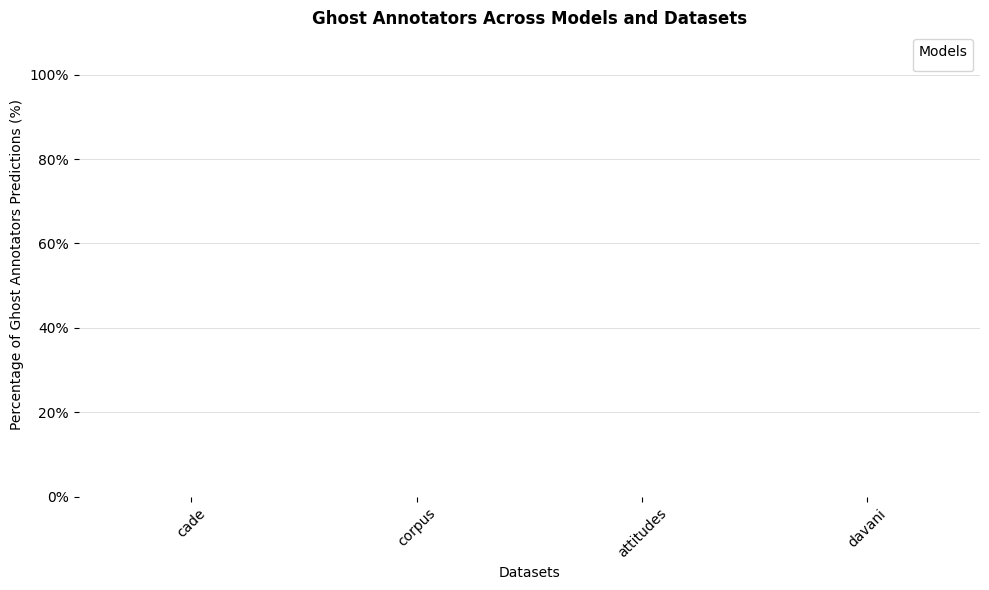

In [ ]:
# Funzione per calcolare la percentuale di predizioni del modello mai selezionate dagli annotatori
def calcola_percentuale_predizioni(file_csv):
    # Leggi il file CSV
    df = pd.read_csv(file_csv)

    # Raggruppa i dati per comment_id e annotator_id
    annotazioni_umanes = df[['comment_id', 'label']].drop_duplicates()

    # Unisce con le predizioni del modello per calcolare la percentuale
    predizioni_modello = df[['comment_id', 'label_model']].drop_duplicates()

    # Raggruppiamo le etichette degli annotatori per ogni comment_id
    annotazioni_per_comment_id = annotazioni_umanes.groupby('comment_id')['label'].apply(set).reset_index()

    # Aggiungiamo le etichette degli annotatori al DataFrame delle predizioni
    df_completo = pd.merge(predizioni_modello, annotazioni_per_comment_id, on='comment_id', how='left')

    count=0
    for index, row in df_completo.iterrows():

        if row['label_model'] not in row['label']:
            #print(row)
            count+=1
    
    print(count,df['comment_id'].nunique())

    # Calcola la percentuale di predizioni "mai selezionate" rispetto al totale delle predizioni per ogni modello e dataset
    model_name, dataset_name = file_csv.split('_')[2], file_csv.split('_')[-1].split(".")[0]
    print(file_csv,model_name,dataset_name)
    if count==0:
        percentuale=0
    else:
        percentuale = count/df['comment_id'].nunique() * 100
    return model_name, dataset_name, percentuale

# Lista dei file CSV nella cartella di output
file_csvs = [f for f in os.listdir(cartella_output) if f.startswith('step_1_') and f.endswith('.csv')]

# Crea un DataFrame vuoto per contenere i risultati
dati_per_grafico = []

# Calcola la percentuale per ogni file CSV
for file_csv in file_csvs:
    model_name, dataset_name, percentuale = calcola_percentuale_predizioni(os.path.join(cartella_output, file_csv))
    dati_per_grafico.append([model_name, dataset_name, percentuale])

# Crea un DataFrame con i risultati
df_risultati = pd.DataFrame(dati_per_grafico, columns=['model_name', 'dataset_name', 'percentuale'])




# Crea un nuovo dataframe con i nomi rimappati per i modelli
df_risultati['model_name'] = df_risultati['model_name'].map(mappatura_modelli)
df_risultati['dataset_name'] = df_risultati['dataset_name'].map(mappatura_dataset)

# Creazione del grafico
plt.figure(figsize=(10, 6))

# Grafico a barre raggruppate con seaborn
modelli_ordinati = ['Llama-3.2-1B',  'Qwen2.5-1.5B','Llama-3.1-8B','Qwen2.5-7B']  # Sostituisci con i tuoi nomi di modello


print(df_risultati['model_name'].unique())
sns.barplot(x='dataset_name', y='percentuale', hue='model_name', data=df_risultati,  hue_order=modelli_ordinati, palette=['#fdae61','#abd9e9','#d7191c','#2c7bb6'], zorder=3)


plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
plt.ylim(0, 110)
plt.legend(title="Models")
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5, zorder=0)  # Griglia orizzontale, grigia chiara
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
# Aggiungi titoli e etichette
plt.title('Ghost Annotators Across Models and Datasets', fontweight='bold')
plt.xlabel('Datasets')
plt.ylabel('Percentage of Ghost Annotators Predictions (%)')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostra il grafico
plt.show()


In [10]:
df_risultati

,model_name,dataset_name,percentuale
0,NaN,cade,63.104326
1,NaN,corpus,55.485163
2,NaN,corpus,50.376321
3,NaN,attitudes,30.143541
4,NaN,attitudes,48.484848
5,NaN,davani,2.898551
6,NaN,cade,61.374046
7,NaN,cade,83.409669
8,NaN,davani,3.096179
9,NaN,attitudes,27.272727
